# Initializing Packages

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import importlib



from src import config
from src import stochastic_processes
from src import market_makers
from src import simulator


importlib.reload(simulator)
importlib.reload(stochastic_processes)
importlib.reload(market_makers)
importlib.reload(config)







<module 'src.config' from 'C:\\Users\\nknobel\\Dropbox\\Cooding\\Avellaneda_Stoikow_market_making\\src\\config.py'>

# Determine the market conditions

In [50]:
S0=100          # Initial stock price
sigma=2         # Stock volatility

money=1000      # Initial money
q=0             # Initial stocks

T = 1.0           # Time horizon
m = 200         # step size
gamma = 0.1     # risk aversion

A = 140     # Buy intensity parameter 1
k = 3/2     # Buy intensity parameter 2


SP=config.SimParams(S0=S0,sigma=sigma,money=money,q=q,T=T,m=m,gamma=gamma,A=A,k=k)

# In this part we simulate one outcome for each Agent

In [51]:

St = stochastic_processes.BM_stock(SP.S0, SP.m, SP.T, 0, SP.sigma)
Buy_a = stochastic_processes.buys(SP.T,SP.m)
Buy_b = stochastic_processes.buys(SP.T,SP.m)


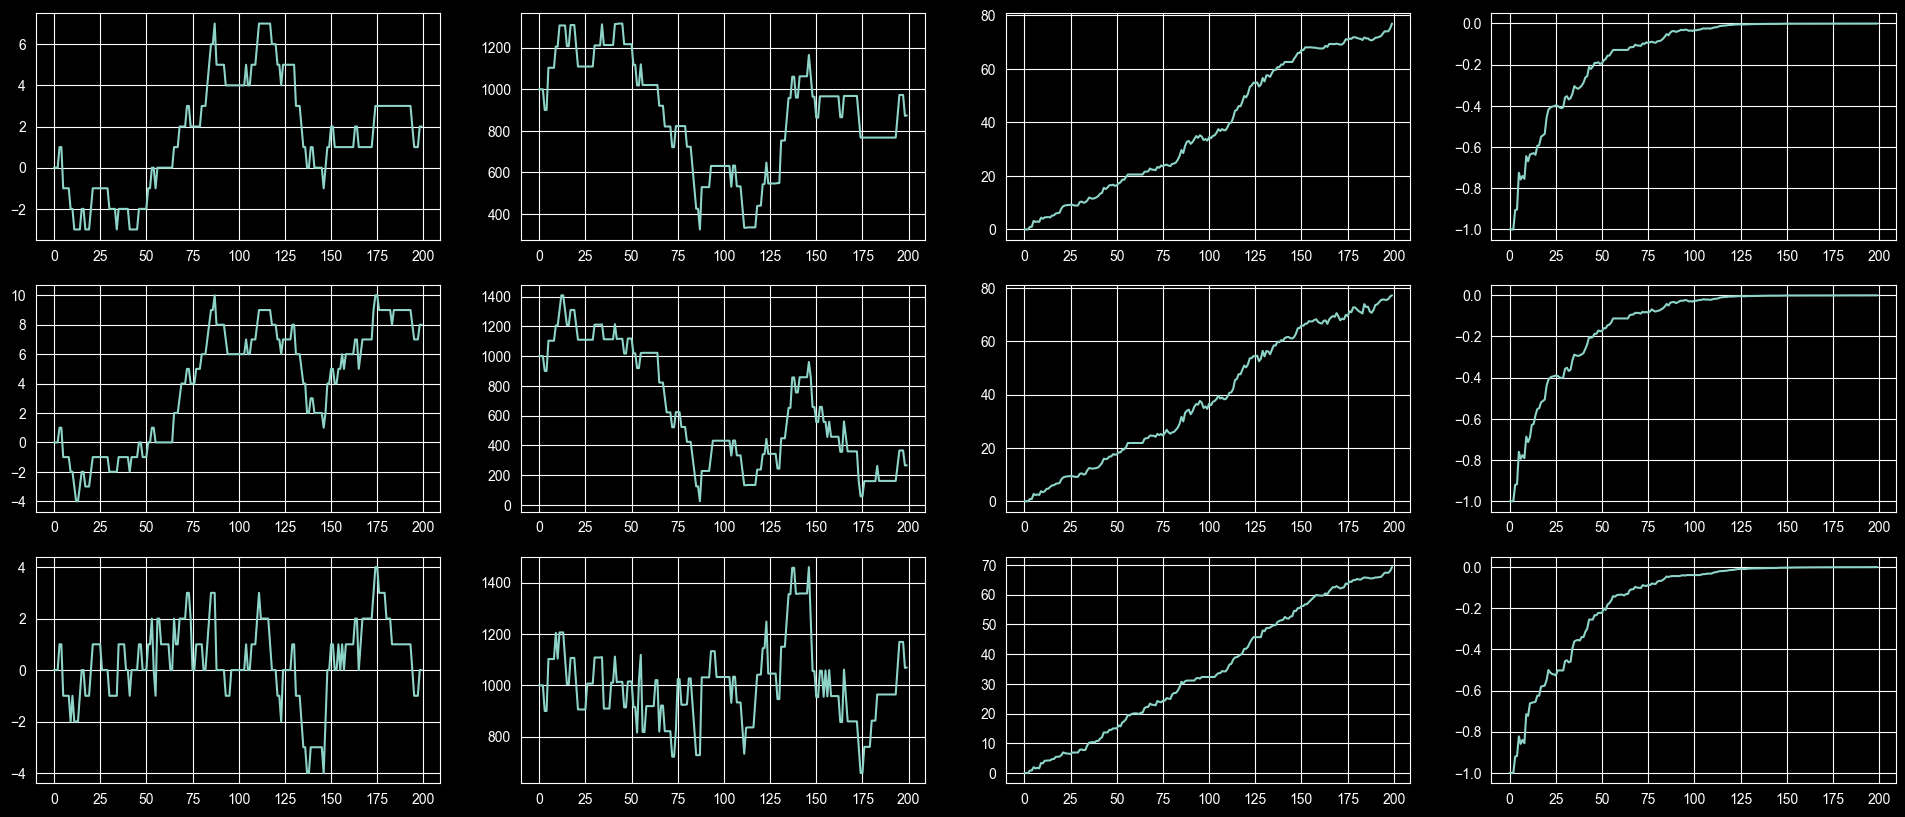

In [52]:


result =simulator.simulation(SP,
                St,
                Buy_a,
                Buy_b,
                market_makers.ConstantSpreadAgent()
                  )
fig, axis = plt.subplots(3,4,figsize=(24,10))
axis[0,0].plot(result['q_stocks'])
axis[0,1].plot(result['money'])
axis[0,2].plot(result['TotalValue']-1000)
axis[0,3].plot(result['value_function'])

result2=simulator.simulation(SP,
                St,
                Buy_a,
                Buy_b,
                market_makers.SymmetricAgent()
                  )

axis[1,0].plot(result2['q_stocks'])
axis[1,1].plot(result2['money'])
axis[1,2].plot(result2['TotalValue']-1000)
axis[1,3].plot(result2['value_function'])



result3=simulator.simulation(SP,
                St,
                Buy_a,
                Buy_b,
                market_makers.ASModelAgent()
                  )

axis[2,0].plot(result3['q_stocks'])
axis[2,1].plot(result3['money'])
axis[2,2].plot(result3['TotalValue']-1000)
axis[2,3].plot(result3['value_function'])

plt.show()


In [41]:
SP

SimParams(S0=100, sigma=2, money=1000, q=0, T=1.0, m=200, gamma=0.1, A=140, k=1.5)

# Here we simulate 10000 paths for each agent

In [42]:

N=10**3


result_const_agent=np.array([0.0,0.0])
result_frozen_agent=np.array([0.0,0.0])
result_AS_agent=np.array([0.0,0.0])

for i in range(N):
    St = stochastic_processes.BM_stock(SP.S0, SP.m, SP.T, 0, SP.sigma)
    Buy_a = stochastic_processes.buys(SP.T,SP.m)
    Buy_b = stochastic_processes.buys(SP.T,SP.m)

    const_agent =simulator.simulation(SP,
                St,
                Buy_a,
                Buy_b,
                market_makers.ConstantSpreadAgent()
                  )
    result_const_agent[0]+=const_agent['TotalValue'][-1]-1000
    result_const_agent[1]+=const_agent['value_function'][-1]

    frozen_agent =simulator.simulation(SP,
                St,
                Buy_a,
                Buy_b,
                market_makers.SymmetricAgent()
                  )
    result_frozen_agent[0]+=frozen_agent['TotalValue'][-1]-1000
    result_frozen_agent[1]+=frozen_agent['value_function'][-1]


    AS_agent =simulator.simulation(SP,
                St,
                Buy_a,
                Buy_b,
                market_makers.ASModelAgent()
                  )
    result_AS_agent[0]+=AS_agent['TotalValue'][-1]-1000
    result_AS_agent[1]+=AS_agent['value_function'][-1]


    #print(result_const_agent[1])




print(result_const_agent/N)
print(result_frozen_agent/N)
print(result_AS_agent/N)


[ 6.07483859e+01 -4.58500238e-03]
[ 6.61724350e+01 -2.76525164e-03]
[ 6.37080718e+01 -2.17178560e-03]
